In [2]:
import pandas as pd


In [3]:
ell = pd.read_csv("Downloader/ellipticals1000.csv")
sp = pd.read_csv("Downloader/spirals1000.csv")
gets = pd.read_csv("Downloader/sdss-wget.sh",header=None)

In [49]:
shGet = gets[gets[0].str.contains(ell['image'][0])]
print(shGet.to_numpy()[0,0])

wget -r -nd --directory-prefix=Field http://das.sdss.org/raw/752/40/corr/5/fpC-000752-r5-0562.fit.gz


In [ ]:
import sep
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u 

ra = ell['ra'][0]
dec = ell['dec'][0]

with fits.open("fpC-000752-r5-0562.fit") as hdul:
    data = hdul[0].data
    header = hdul[0].header
data = data.astype(float)
wcs = WCS(header)

skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
x_target, y_target = wcs.world_to_pixel(skycoord)

bkg = sep.Background(data)
data = data - bkg

objects = sep.extract(data, 2.5, err=bkg.globalrms)
detected = np.argmin((objects["x"]-x_target)**2+(objects["y"]-y_target)**2)

img = data[objects[detected]["ymin"]:objects[detected]["ymax"],objects[detected]["xmin"]:objects[detected]["xmax"]]
preprocessed = -np.log(img)
preprocessed = np.nan_to_num(preprocessed,posinf=0.0,neginf=0.0,nan=0.0)
preprocessed = (preprocessed-np.average(preprocessed))/np.std(preprocessed)

STRIP   ='S          '         / Strip in the stripe being tracked.              [astropy.io.fits.card]
FLAVOR  ='science    '         / Flavor of this run                              [astropy.io.fits.card]
SYS_SCN ='mean       '         / System of the scan great circle (e.g., mean)    [astropy.io.fits.card]
OBJECT  ='10 S       '         / e.g., 'stripe 50.6 degrees, north strip'        [astropy.io.fits.card]
EXPTIME ='53.907456'           / Exposure time (seconds)                         [astropy.io.fits.card]
DAVERS  ='v12_6   '            / Version of DA software                          [astropy.io.fits.card]
 [astropy.io.fits.verify]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Changed DATE-OBS from '21/03/99' to '1999-03-21''. [astropy.wcs.wcs]
/tmp/ipykernel_17639/2463186737.py:27: RuntimeWarning: invalid value encountered in log
  preprocessed = -np.log(img)


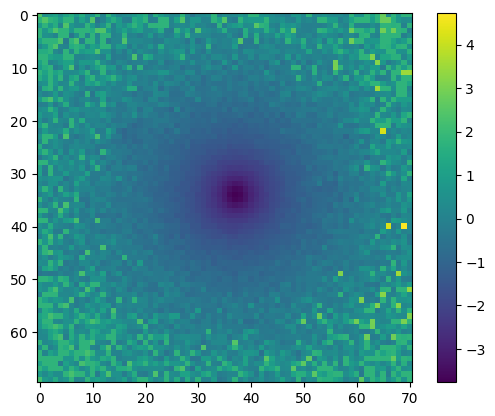

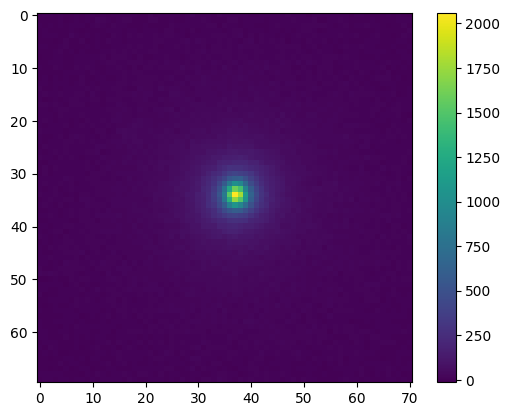

In [47]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(preprocessed)
plt.colorbar()
plt.figure()
plt.imshow(img)
plt.colorbar()
plt.show()
np.save("preprocessed.npy", preprocessed)

# Automatic Download Cut and Cleaning

In [6]:
import sep
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u 
import os


ell = pd.read_csv("Downloader/ellipticals1000.csv")
sp = pd.read_csv("Downloader/spirals1000.csv")
gets = pd.read_csv("Downloader/sdss-wget.sh",header=None)

for index in range(0,len(sp)):
    ra = sp['ra'][index]
    dec = sp['dec'][index]
    shGet = gets[gets[0].str.contains(sp['image'][index])].to_numpy()[0,0]
    print(shGet)
    os.system(shGet)
    os.system("gzip -d Field/"+sp['image'][index])

    with fits.open("Field/"+sp['image'][index][:-3]) as hdul:
        data = hdul[0].data
        header = hdul[0].header
    data = data.astype(float)
    wcs = WCS(header)

    skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
    x_target, y_target = wcs.world_to_pixel(skycoord)

    bkg = sep.Background(data)
    data = data - bkg

    objects = sep.extract(data, 2.5, err=bkg.globalrms)
    detected = np.argmin((objects["x"]-x_target)**2+(objects["y"]-y_target)**2)

    img = data[objects[detected]["ymin"]:objects[detected]["ymax"],objects[detected]["xmin"]:objects[detected]["xmax"]]
    preprocessed = -np.log(img)
    preprocessed = np.nan_to_num(preprocessed,posinf=0.0,neginf=0.0,nan=0.0)
    preprocessed = (preprocessed-np.average(preprocessed))/np.std(preprocessed)
    np.save(f"galaxies2sigma/sp{index}.npy", preprocessed)
    os.system("rm -rf Field/"+sp['image'][index][:-3])

wget -r -nd --directory-prefix=Field http://das.sdss.org/raw/4632/40/corr/4/fpC-004632-r4-0178.fit.gz


--2025-05-24 18:54:10--  http://das.sdss.org/raw/4632/40/corr/4/fpC-004632-r4-0178.fit.gz
Resolving das.sdss.org (das.sdss.org)... 128.220.233.141
Connecting to das.sdss.org (das.sdss.org)|128.220.233.141|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2236374 (2,1M) [application/x-gzip]
Saving to: ‘Field/fpC-004632-r4-0178.fit.gz’

     0K .......... .......... .......... .......... ..........  2%  183K 12s
    50K .......... .......... .......... .......... ..........  4%  182K 11s
   100K .......... .......... .......... .......... ..........  6%  182K 11s
   150K .......... .......... .......... .......... ..........  9%  365K 10s
   200K .......... .......... .......... .......... .......... 11%  183K 10s
   250K .......... .......... .......... .......... .......... 13%  182K 9s
   300K .......... .......... .......... .......... .......... 16%  364K 9s
   350K .......... .......... .......... .......... .......... 18%  365K 8s
   400K .......... ........

wget -r -nd --directory-prefix=Field http://das.sdss.org/raw/3518/40/corr/2/fpC-003518-r2-0037.fit.gz


connected.
HTTP request sent, awaiting response... 200 OK
Length: 2399427 (2,3M) [application/x-gzip]
Saving to: ‘Field/fpC-003518-r2-0037.fit.gz’

     0K .......... .......... .......... .......... ..........  2%  121K 19s
    50K .......... .......... .......... .......... ..........  4%  121K 19s
   100K .......... .......... .......... .......... ..........  6%  181K 16s
   150K .......... .......... .......... .......... ..........  8%  183K 15s
   200K .......... .......... .......... .......... .......... 10%  182K 14s
   250K .......... .......... .......... .......... .......... 12%  367K 12s
   300K .......... .......... .......... .......... .......... 14%  360K 11s
   350K .......... .......... .......... .......... .......... 17%  364K 10s
   400K .......... .......... .......... .......... .......... 19%  362K 9s
   450K .......... .......... .......... .......... .......... 21%  209M 8s
   500K .......... .......... .......... .......... .......... 23%  368K 8s
   550K 

wget -r -nd --directory-prefix=Field http://das.sdss.org/raw/4670/40/corr/3/fpC-004670-r3-0090.fit.gz


...

wget -r -nd --directory-prefix=Field http://das.sdss.org/raw/2738/40/corr/4/fpC-002738-r4-0083.fit.gz


connected.
HTTP request sent, awaiting response... 200 OK
Length: 2355026 (2,2M) [application/x-gzip]
Saving to: ‘Field/fpC-002738-r4-0083.fit.gz’

     0K .......... .......... .......... .......... ..........  2%  119K 19s
    50K .......... .......... .......... .......... ..........  4%  180K 15s
   100K .......... .......... .......... .......... ..........  6%  180K 14s
   150K .......... .......... .......... .......... ..........  8%  180K 13s
   200K .......... .......... .......... .......... .......... 10%  181K 13s
   250K .......... .......... .......... .......... .......... 13%  360K 11s
   300K .......... .......... .......... .......... .......... 15%  180K 11s
   350K .......... .......... .......... .......... .......... 17%  360K 10s
   400K .......... .......... .......... .......... .......... 19%  181K 10s
   450K .......... .......... .......... .......... .......... 21%  358K 9s
   500K .......... .......... .......... .......... .......... 23%  179K 9s
   550K

wget -r -nd --directory-prefix=Field http://das.sdss.org/raw/4344/40/corr/5/fpC-004344-r5-0075.fit.gz


--2025-05-24 19:23:19--  http://das.sdss.org/raw/4344/40/corr/5/fpC-004344-r5-0075.fit.gz
Resolving das.sdss.org (das.sdss.org)... 128.220.233.141
Connecting to das.sdss.org (das.sdss.org)|128.220.233.141|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2297423 (2,2M) [application/x-gzip]
Saving to: ‘Field/fpC-004344-r5-0075.fit.gz’

     0K .......... .......... .......... .......... ..........  2%  179K 12s
    50K .......... .......... .......... .......... ..........  4%  178K 12s
   100K .......... .......... .......... .......... ..........  6%  178K 12s
   150K .......... .......... .......... .......... ..........  8%  360K 10s
   200K .......... .......... .......... .......... .......... 11% 87,2M 8s
   250K .......... .......... .......... .......... .......... 13%  353K 7s
   300K .......... .......... .......... .......... .......... 15%  354K 7s
   350K .......... .......... .......... .......... .......... 17%  356K 6s
   400K .......... .........

FileNotFoundError: [Errno 2] No such file or directory: 'Field/fpC-004344-r5-0075.fit'